In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from numpy.random import default_rng

seed = 42
rng = default_rng(42)

from matplotlib.font_manager import FontProperties

font = FontProperties()
font.set_family("serif")
font.set_name("DejaVu Sans")

In [3]:
with open("results_natural_10_500_300.pkl", "rb") as f:
    all_idata, G_dim, disrupting_pattern_indices = pickle.load(f)

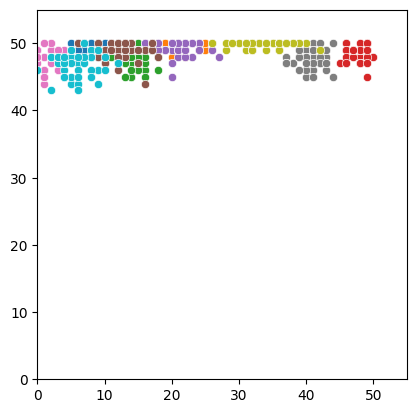

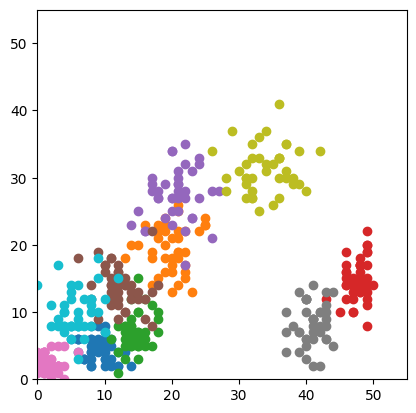

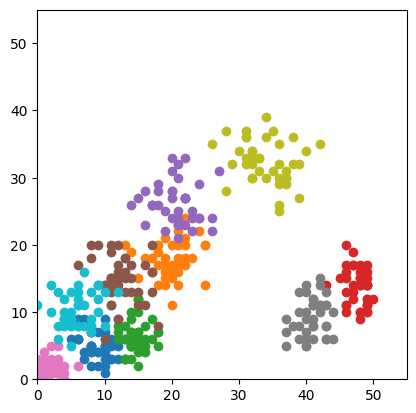

In [4]:
# colors = plt.cm.tab10(range(len(all_idata)))
# fig, axs = plt.subplots(nrows=1, ncols=3, dpi=300, sharey=True, tight_layout=True)
fig_exc, ax_exc = plt.subplots()
fig_dis1, ax_dis1 = plt.subplots()
fig_dis2, ax_dis2 = plt.subplots()
mei_rates = []
completing_rates = []
disrupting_1_rates = []
disrupting_2_rates = []
for idx, (idata_set, disrupting_pattern_idx) in enumerate(
    zip(all_idata, disrupting_pattern_indices)
):
    center_x_id = 4 * G_dim + idx

    # idata['posterior']['X'].data.shape = (n_chains, n_samples, n_x_dims)
    mei_firing_rates = (
        idata_set[0].posterior.X.data[:, :, center_x_id].reshape(50, 40).sum(axis=0)
    )
    mei_rates.append(mei_firing_rates)
    completing_firing_rates = (
        idata_set[1].posterior.X.data[:, :, center_x_id].reshape(50, 40).sum(axis=0)
    )
    completing_rates.append(completing_firing_rates)
    disrupting_1_firing_rates = (
        idata_set[2].posterior.X.data[:, :, center_x_id].reshape(50, 40).sum(axis=0)
    )
    disrupting_1_rates.append(disrupting_1_firing_rates)
    disrupting_2_firing_rates = (
        idata_set[3].posterior.X.data[:, :, center_x_id].reshape(50, 40).sum(axis=0)
    )
    disrupting_2_rates.append(disrupting_2_firing_rates)
    sns.scatterplot(x=mei_firing_rates, y=completing_firing_rates, ax=ax_exc)
    # ax_exc.scatter(mei_firing_rates, completing_firing_rates)
    ax_exc.set_xlim(0, 55)
    ax_exc.set_ylim(0, 55)
    # make square
    ax_exc.set_box_aspect(1)

    ax_dis1.scatter(mei_firing_rates, disrupting_1_firing_rates)
    ax_dis1.set_xlim(0, 55)
    ax_dis1.set_ylim(0, 55)
    # make square
    ax_dis1.set_box_aspect(1)

    ax_dis2.scatter(mei_firing_rates, disrupting_2_firing_rates)
    ax_dis2.set_xlim(0, 55)
    ax_dis2.set_ylim(0, 55)
    # make square
    ax_dis2.set_box_aspect(1)

In [5]:
mei_rates = np.array(mei_rates)
completing_rates = np.array(completing_rates)
disrupting_1_rates = np.array(disrupting_1_rates)
disrupting_2_rates = np.array(disrupting_2_rates)

In [6]:
print(mei_rates.shape)
print(completing_rates.shape)
print(disrupting_1_rates.shape)
print(disrupting_2_rates.shape)

(10, 40)
(10, 40)
(10, 40)
(10, 40)


In [7]:
all_mei_means = mei_rates.mean(axis=1)
all_completing_means = completing_rates.mean(axis=1)
all_disrupting_1_means = disrupting_1_rates.mean(axis=1)
all_disrupting_2_means = disrupting_2_rates.mean(axis=1)

In [8]:
all_mei_rates = mei_rates.flatten()
all_completing_rates = completing_rates.flatten()
all_disrupting_1_rates = disrupting_1_rates.flatten()

all_disrupting_2_rates = disrupting_2_rates.flatten()

In [9]:
xlim = 55
ylim = 55
last_xtick = 50
last_ytick = 50
noise = 1
dot_size = 10
dot_alpha = 0.30
star_size = 120
labelsize = 20

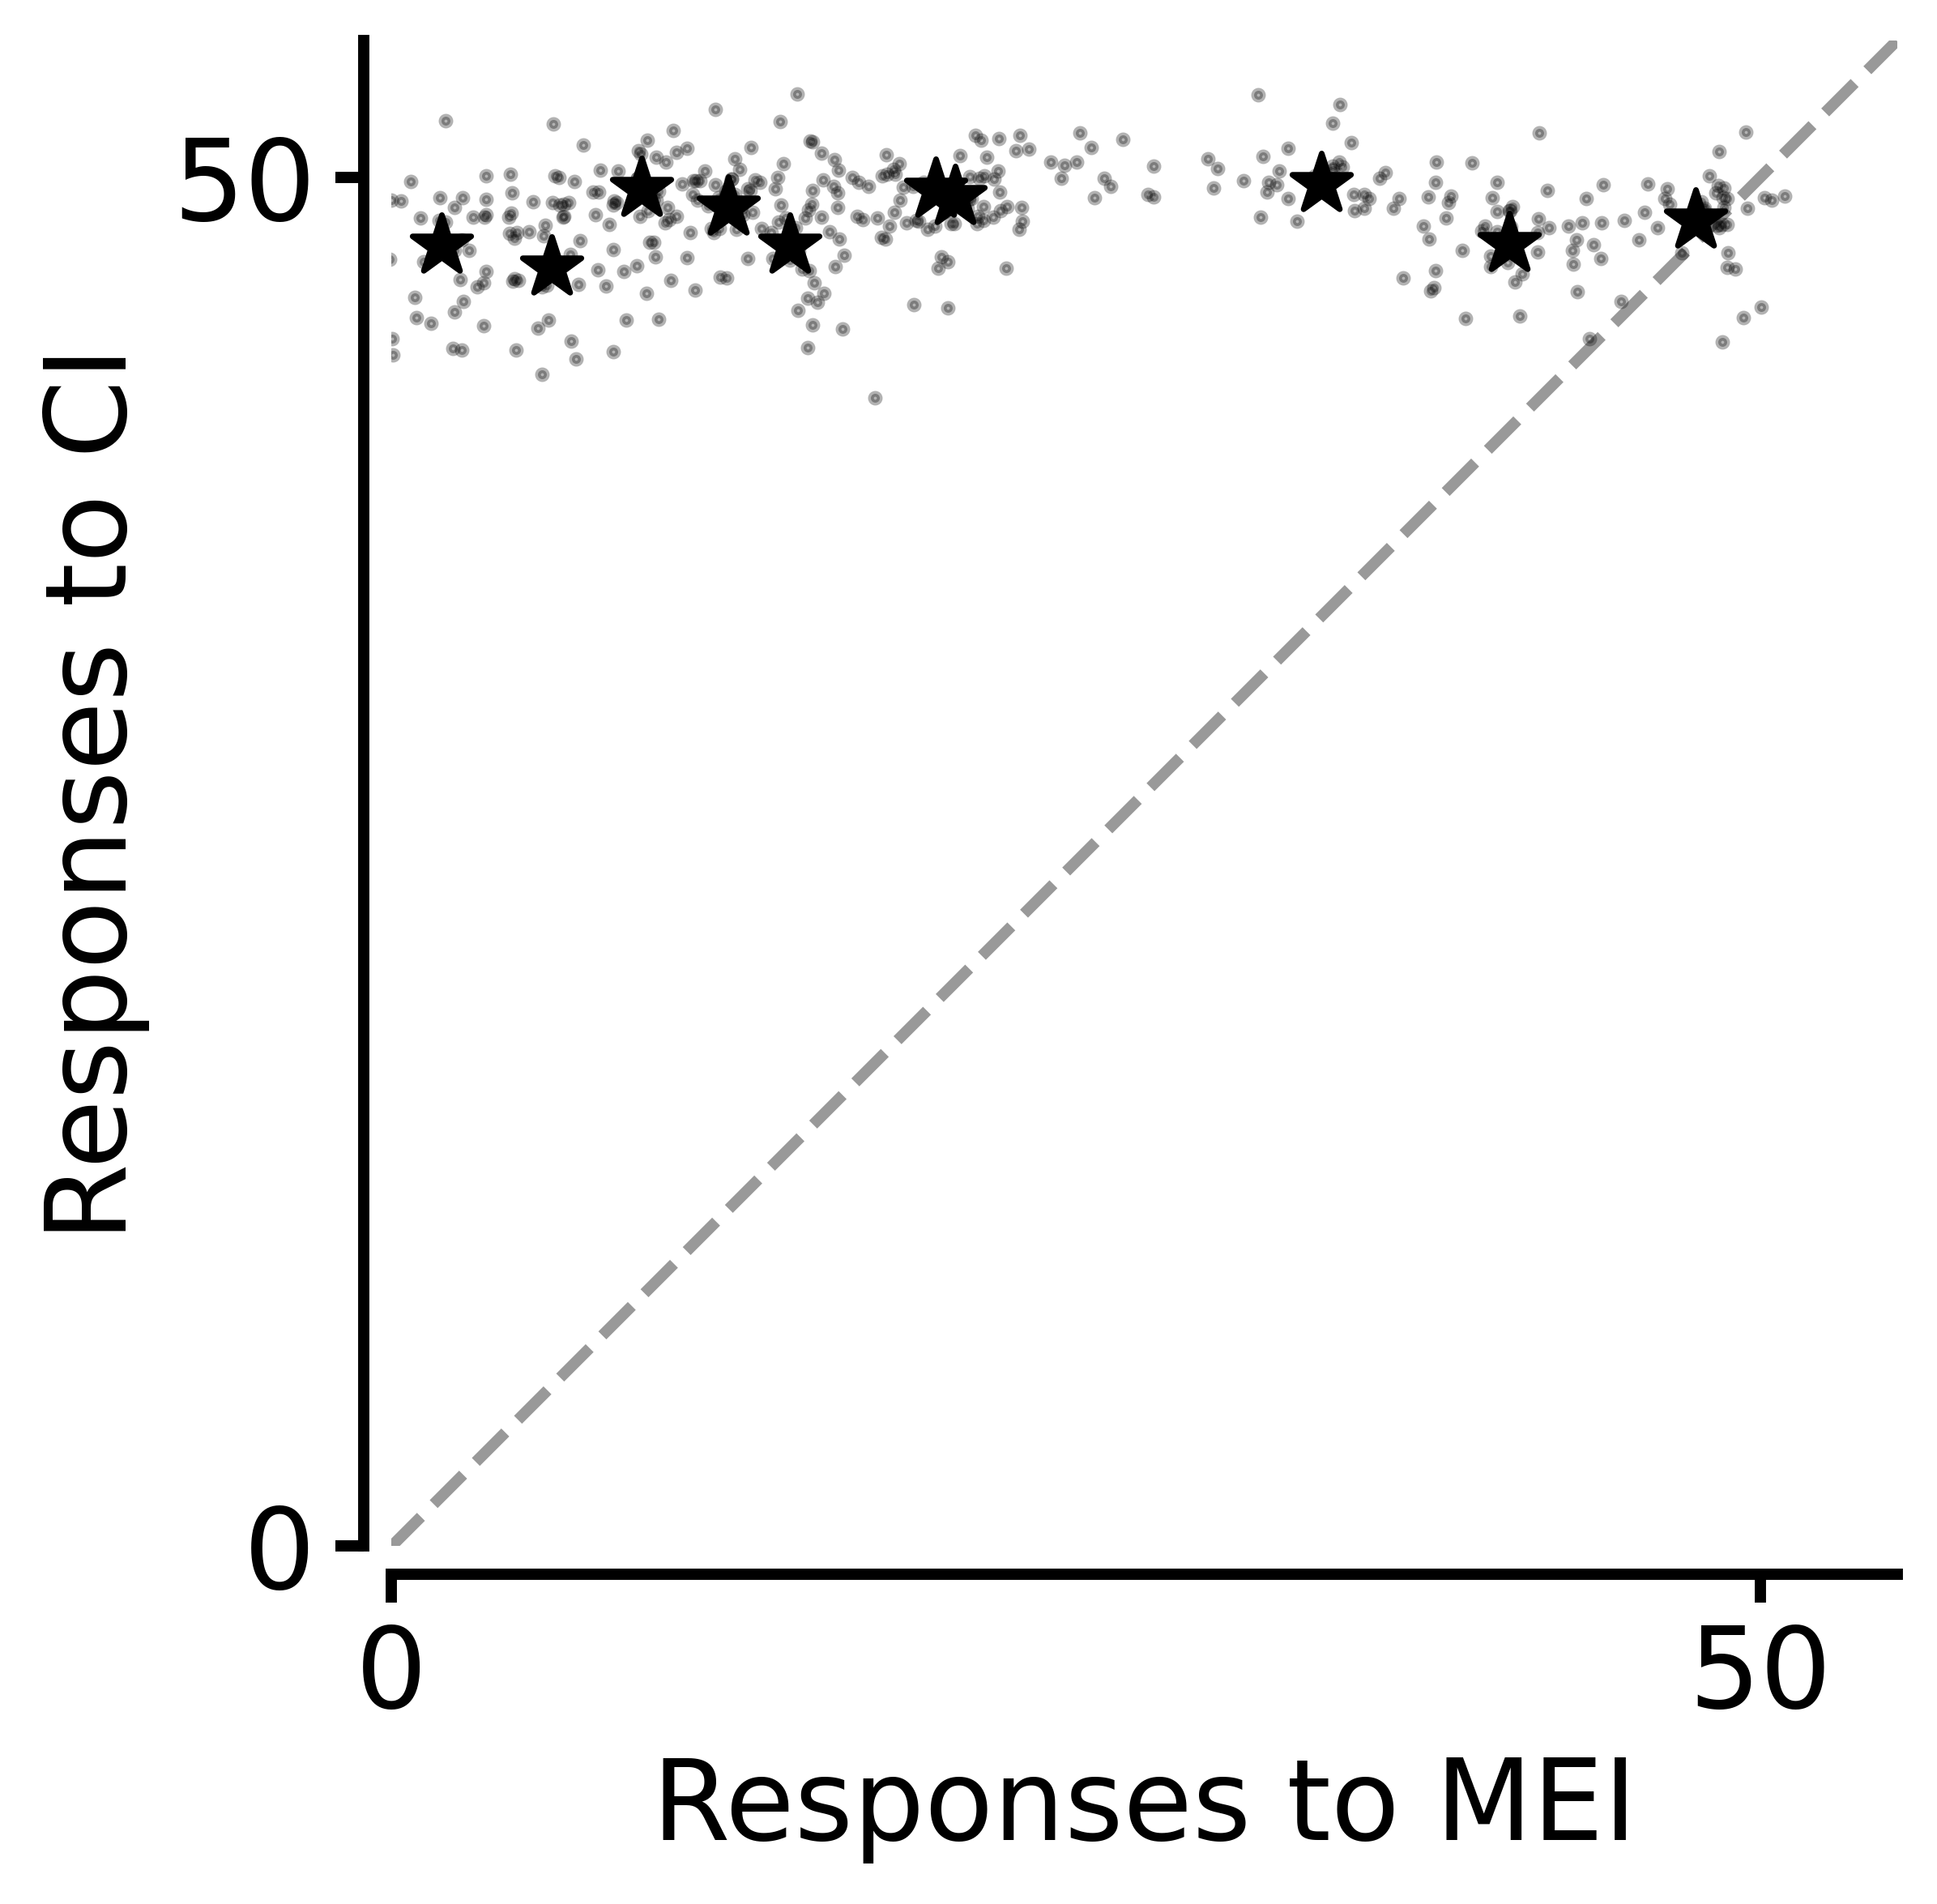

In [13]:
fig, ax = plt.subplots(dpi=500)
ax.plot([0, xlim], [0, ylim], color="black", linestyle="--", linewidth=2, alpha=0.4)
x = all_mei_rates + rng.normal(0, noise, len(all_mei_rates))
y = all_completing_rates + rng.normal(0, noise, len(all_completing_rates))
ax.scatter(x, y, marker=".", s=dot_size, color="black", alpha=dot_alpha)
ax.scatter(
    all_mei_means,
    all_completing_means,
    marker="*",
    s=star_size,
    color="black",
)
# draw a regression line
# m, b = np.polyfit(all_mei_means, all_completing_means, 1)
# x_ = np.linspace(0, 50, 55)
# y_ = m * x_ + b
# ax.plot(x_, y_, color='black', linestyle='-', linewidth=1)
# ax.plot(, color='gray', linestyle='--')
ax.set_xlim(0, xlim)
ax.set_ylim(0, ylim)
ax.set_xticks([0, last_xtick])
ax.set_yticks([0, last_ytick])
ax.tick_params(axis="both", which="major", labelsize=labelsize, width=2, length=5)
# draw diagonal line
# make square
ax.set_box_aspect(1)
ax.set_xlabel("Responses to MEI", fontsize=20)
ax.set_ylabel("Responses to CI", fontsize=20)
ax.spines[["left", "bottom"]].set_linewidth(2)

sns.despine(ax=ax, offset=5)
fig.tight_layout()
fig.savefig("mei_vs_completing.pdf", transparent=True)

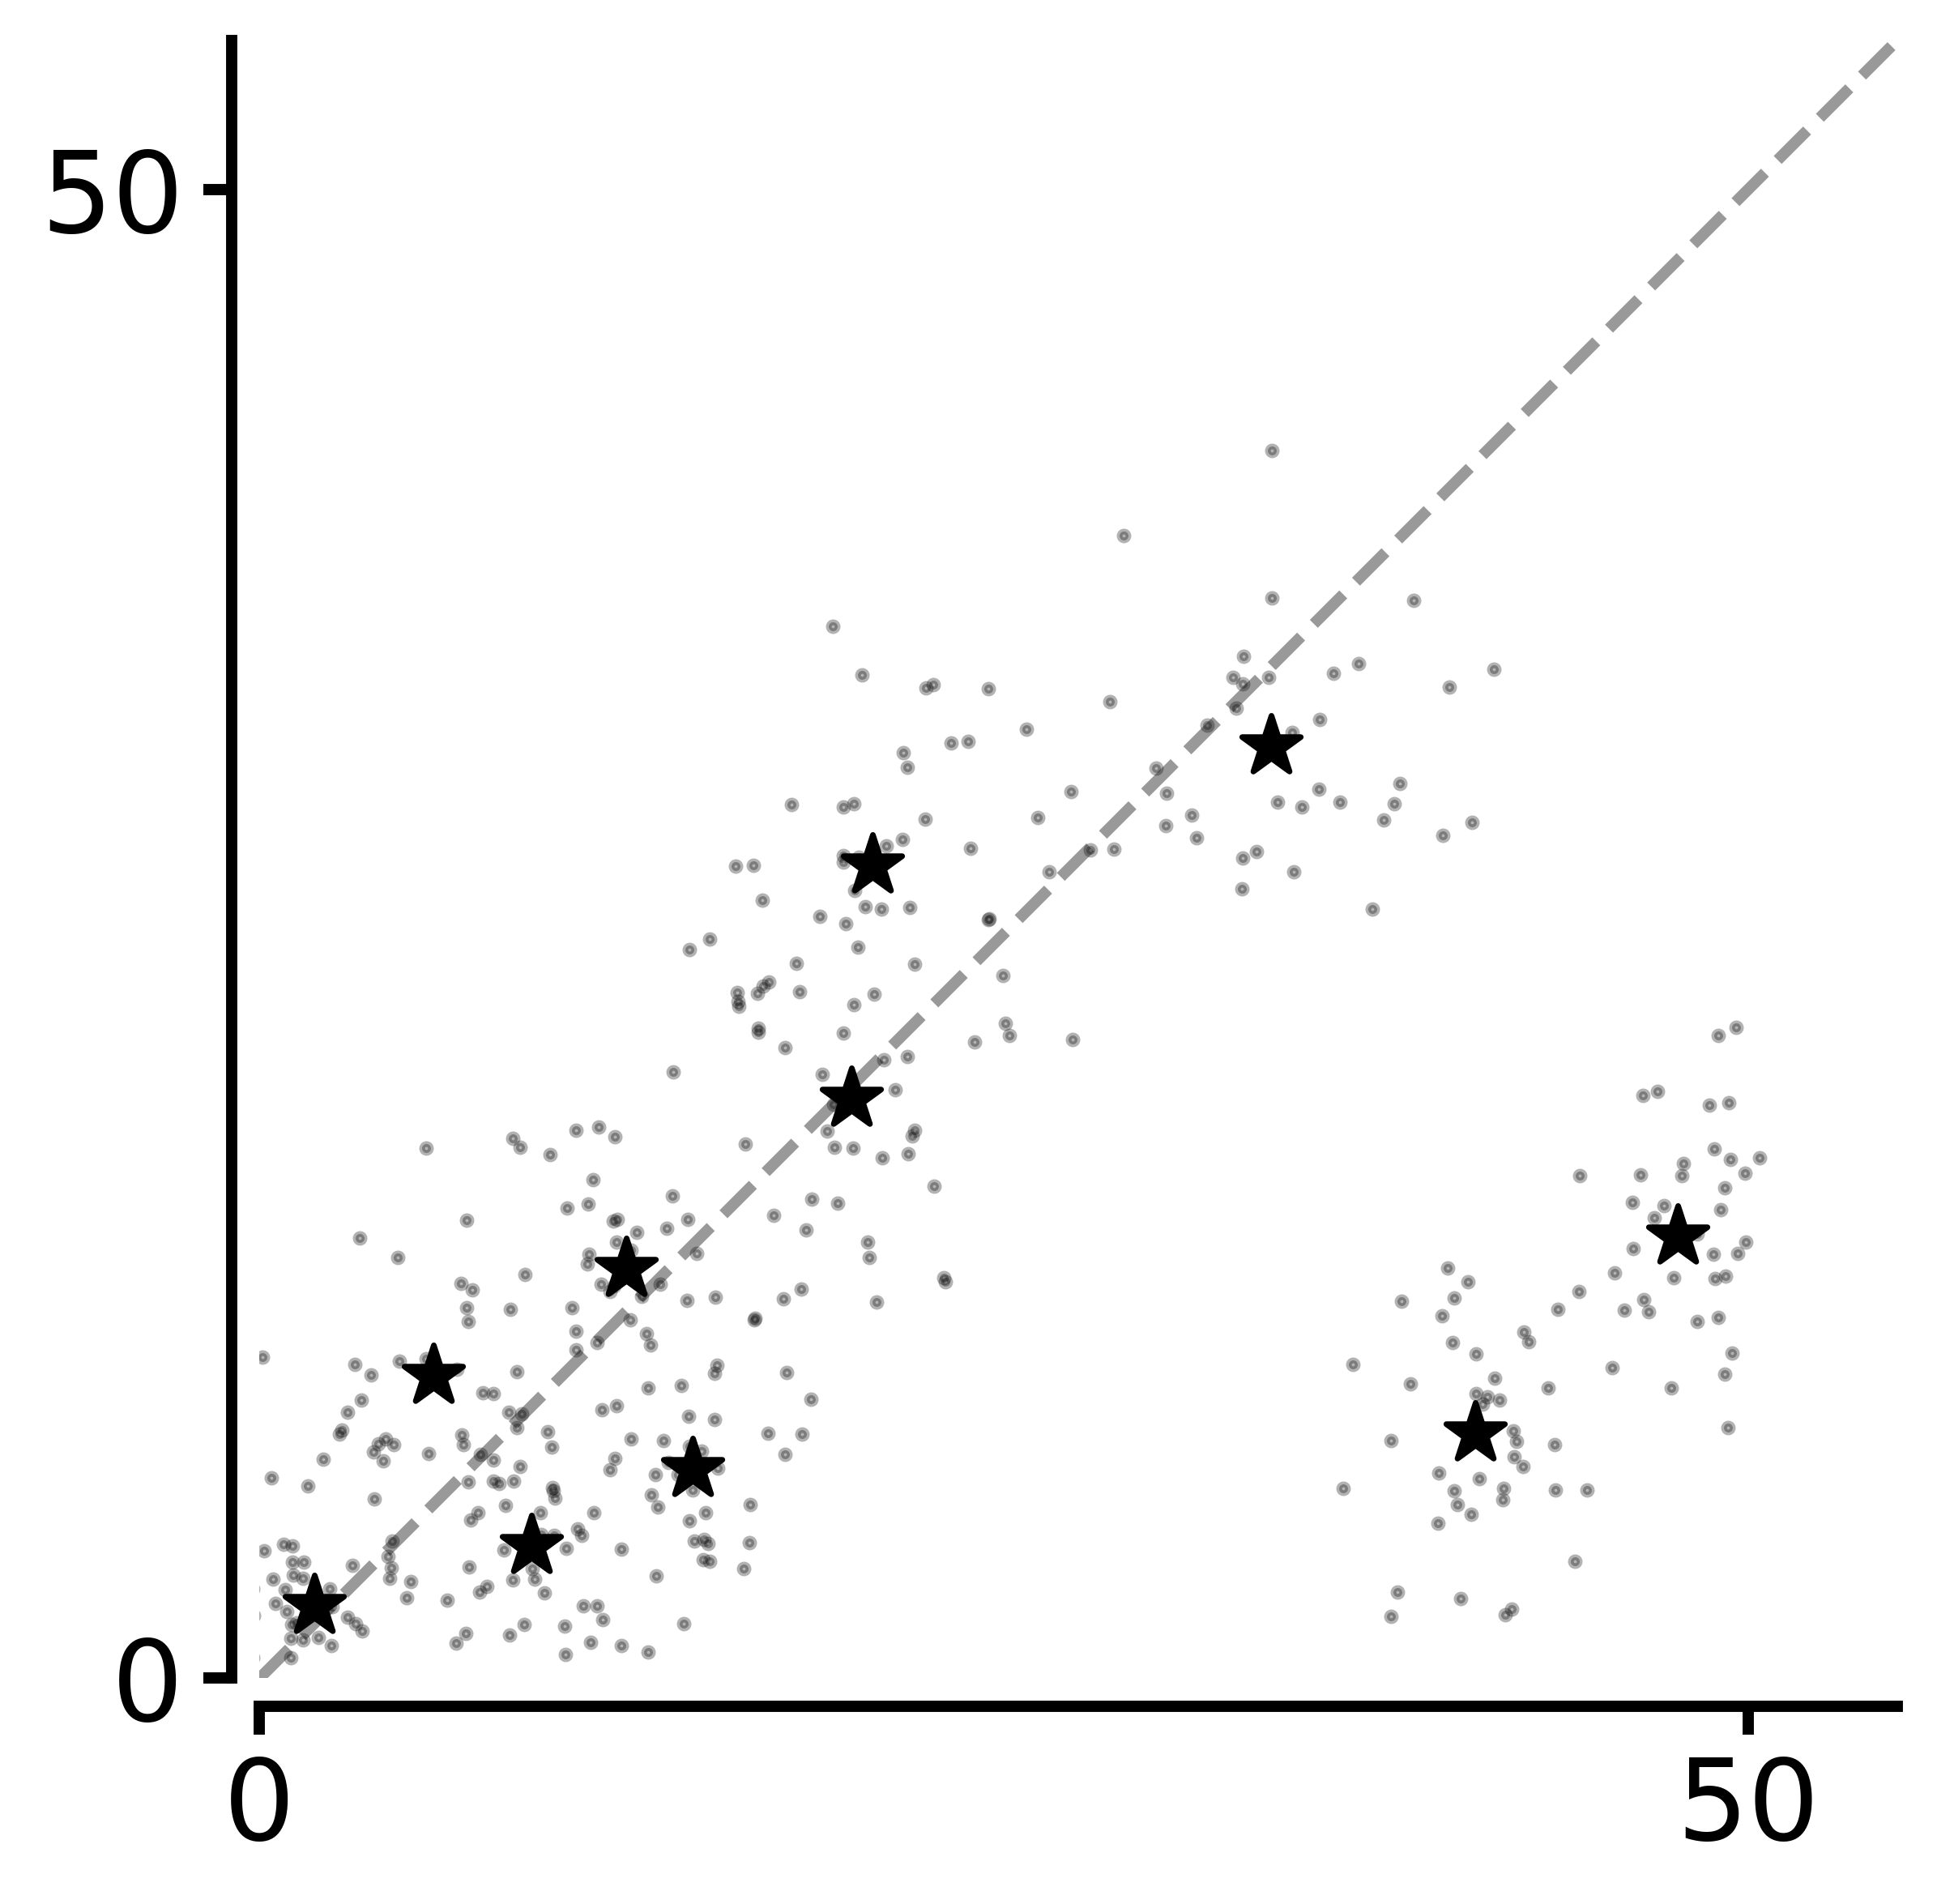

In [11]:
fig, ax = plt.subplots(dpi=500)
ax.plot([0, xlim], [0, ylim], color="black", linestyle="--", linewidth=2, alpha=0.4)
x = all_mei_rates + rng.normal(0, noise, len(all_mei_rates))
y = all_disrupting_1_rates + rng.normal(0, noise, len(all_completing_rates))
ax.scatter(x, y, marker=".", s=dot_size, color="black", alpha=dot_alpha)
ax.scatter(
    all_mei_means,
    all_disrupting_1_means,
    marker="*",
    s=star_size,
    color="black",
)
# draw a regression line
# m, b = np.polyfit(all_mei_means, all_completing_means, 1)
# x_ = np.linspace(0, 50, 55)
# y_ = m * x_ + b
# ax.plot(x_, y_, color='black', linestyle='-', linewidth=1)
# ax.plot(, color='gray', linestyle='--')
ax.set_xlim(0, xlim)
ax.set_ylim(0, ylim)
ax.set_xticks([0, last_xtick])
ax.set_yticks([0, last_ytick])
ax.tick_params(axis="both", which="major", labelsize=labelsize, width=2, length=5)
# draw diagonal line
# make square
ax.set_box_aspect(1)
# ax.set_xlabel("Responses to MEI", fontsize=20)
# ax.set_ylabel("Responses to DI1", fontsize=20)
ax.spines[["left", "bottom"]].set_linewidth(2)

sns.despine(ax=ax, offset=5)
fig.tight_layout()
fig.savefig("mei_vs_disrupting_1.pdf", transparent=True)

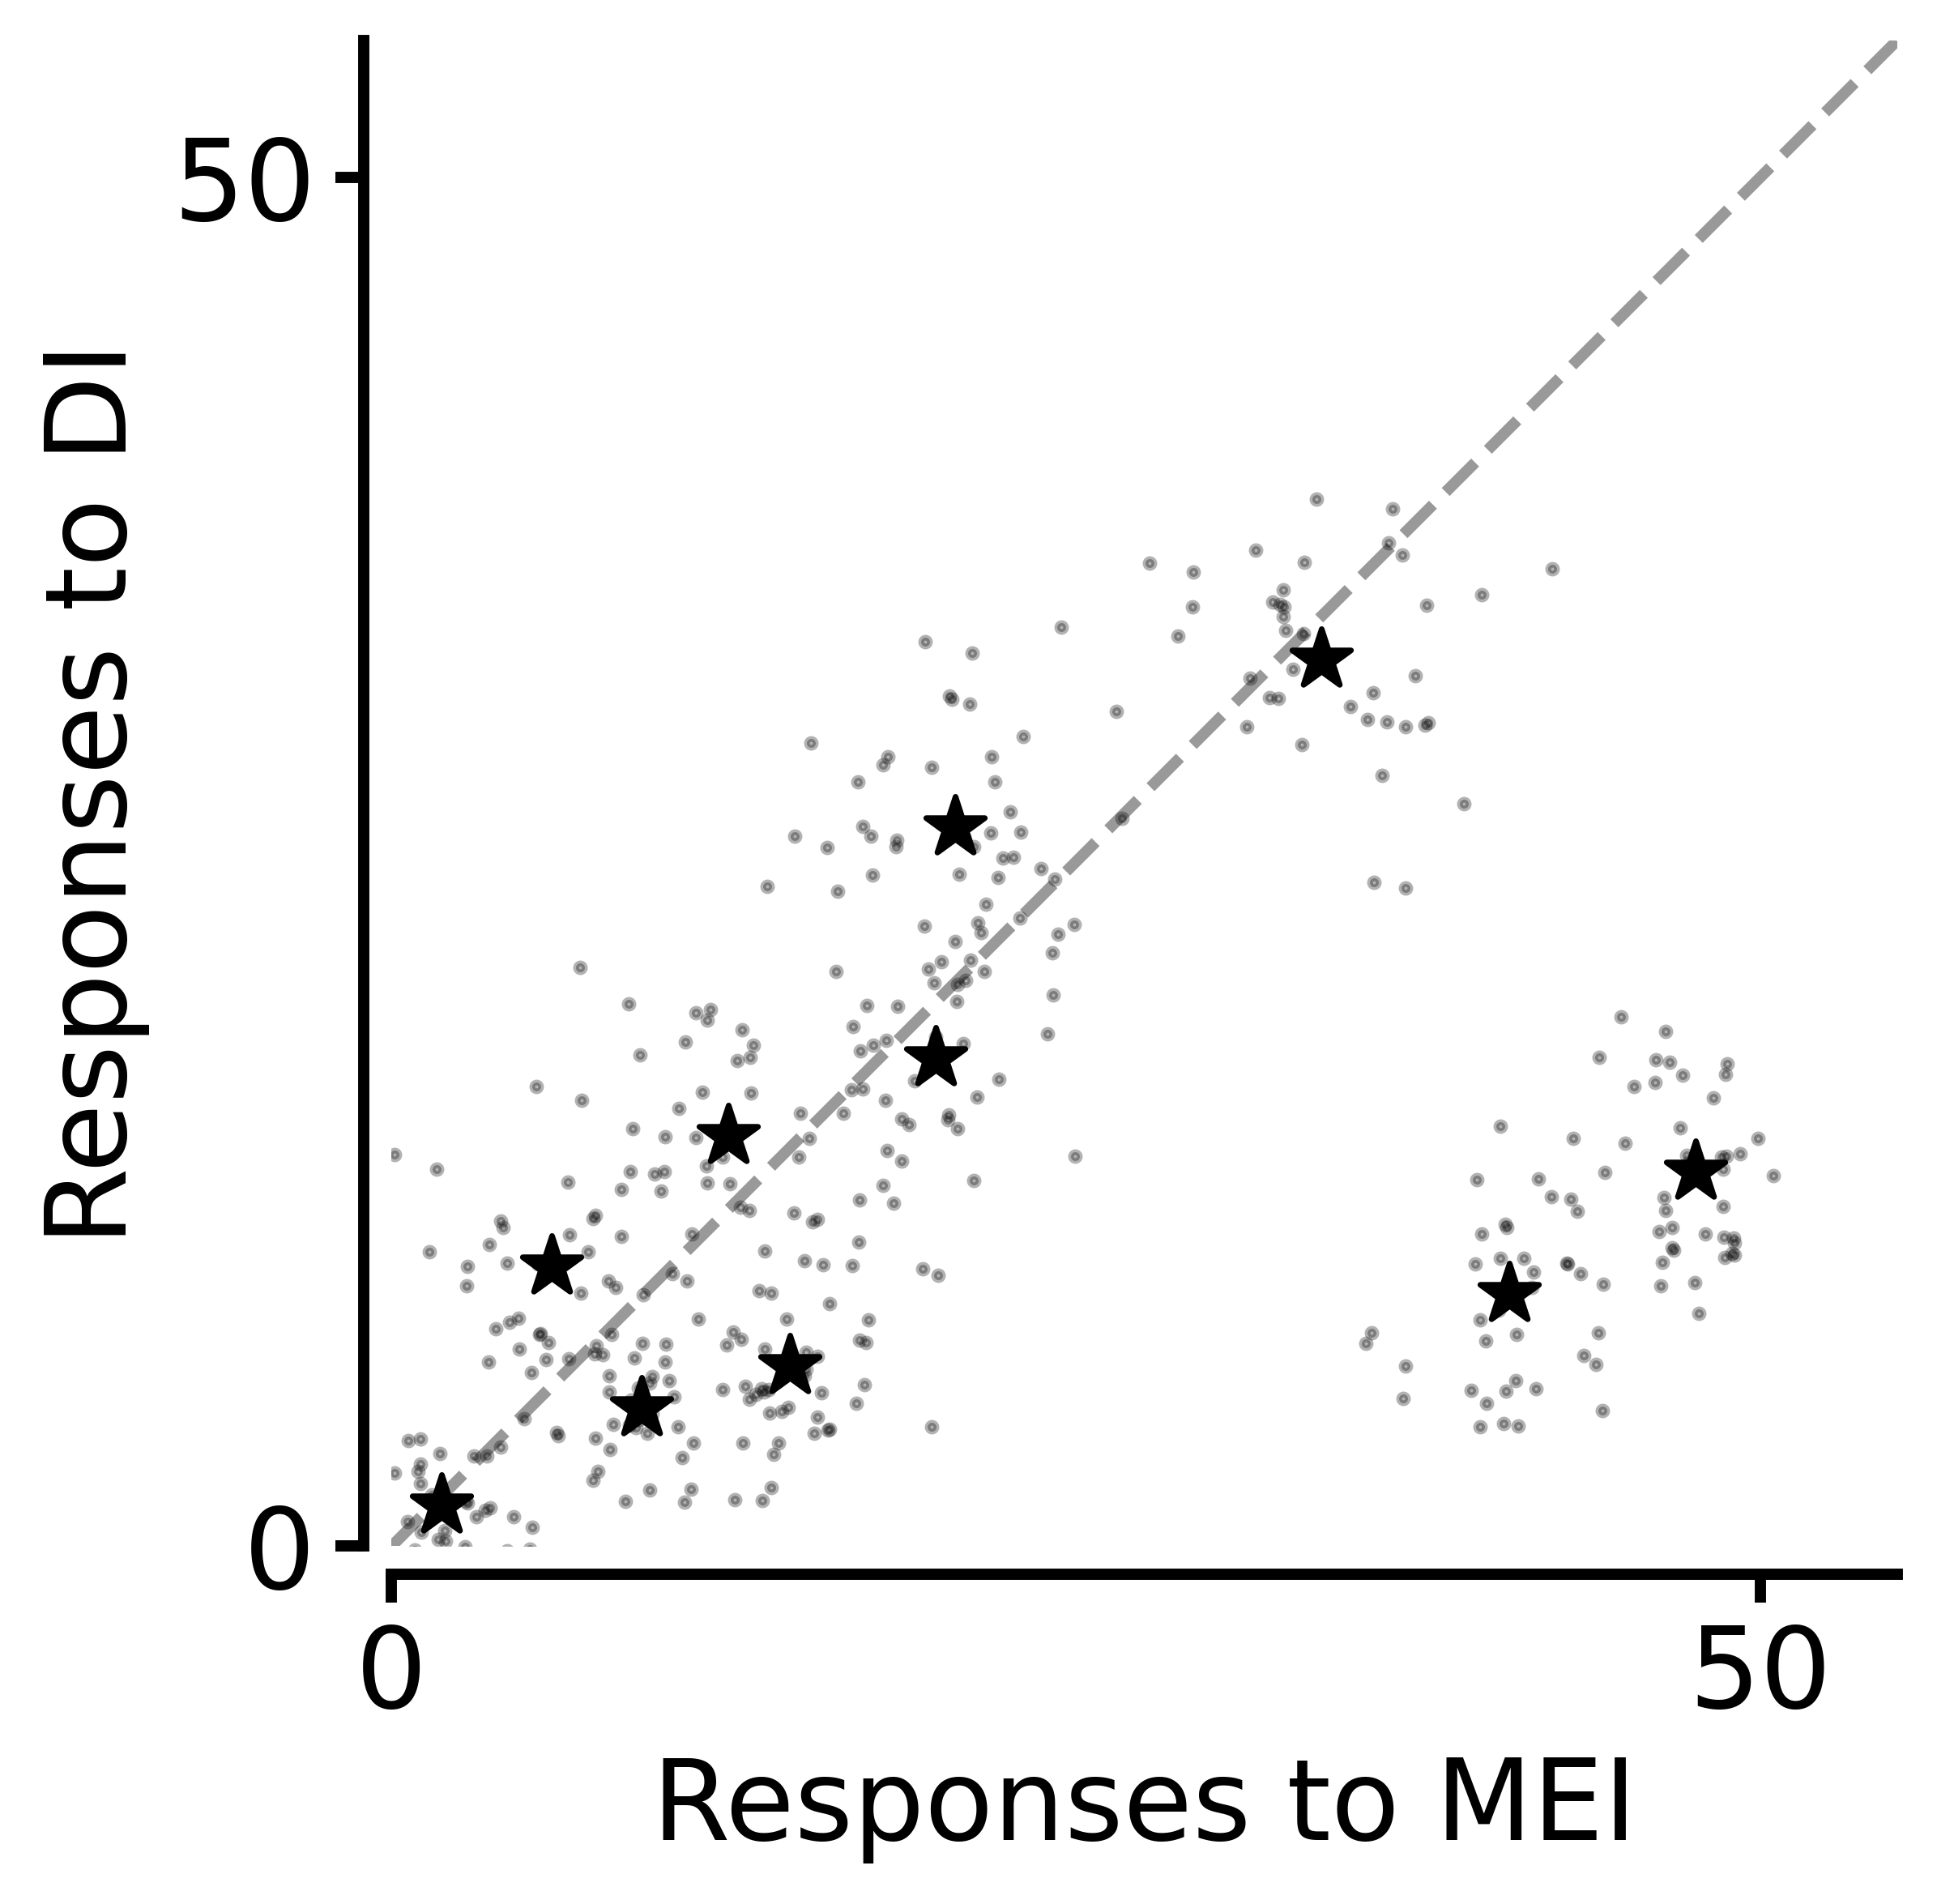

In [14]:
fig, ax = plt.subplots(dpi=500)
ax.plot([0, xlim], [0, ylim], color="black", linestyle="--", linewidth=2, alpha=0.4)
x = all_mei_rates + rng.normal(0, noise, len(all_mei_rates))
y = all_disrupting_2_rates + rng.normal(0, noise, len(all_completing_rates))
ax.scatter(x, y, marker=".", s=dot_size, color="black", alpha=dot_alpha)
ax.scatter(
    all_mei_means,
    all_disrupting_2_means,
    marker="*",
    s=star_size,
    color="black",
)
# draw a regression line
# m, b = np.polyfit(all_mei_means, all_completing_means, 1)
# x_ = np.linspace(0, 50, 55)
# y_ = m * x_ + b
# ax.plot(x_, y_, color='black', linestyle='-', linewidth=1)
# ax.plot(, color='gray', linestyle='--')
ax.set_xlim(0, xlim)
ax.set_ylim(0, ylim)
ax.set_xticks([0, last_xtick])
ax.set_yticks([0, last_ytick])
ax.tick_params(axis="both", which="major", labelsize=labelsize, width=2, length=5)
# draw diagonal line
# make square
ax.set_box_aspect(1)
ax.set_xlabel("Responses to MEI", fontsize=20)
ax.set_ylabel("Responses to DI", fontsize=20)
ax.spines[["left", "bottom"]].set_linewidth(2)

sns.despine(ax=ax, offset=5)
fig.tight_layout()
fig.savefig("mei_vs_disrupting_2.pdf", transparent=True)